## Experiment Analysis: Number of Superpixels

This notebook analyzes the results obtained as the number of superpixels varies for the dataset in question. Each image used in the construction of the convolutional filters presents the same number of superpixels using the technique presented in iftDISF.

In [4]:
# Library imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path
from collections import Counter
from collections import defaultdict
from scipy.stats import wilcoxon
from scipy import stats

# Visualization settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Display the dataframe to fit nicely on the screen
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)

#### 1. Data Loading, Processing and Save

Loading the experiment-generated files and converting them into a structured DataFrame for analysis.

In [5]:
# Path to the experiments directory
dir_experiments = "../experiments/nsuperpixels/results"

# Dicionários separados
results_files = defaultdict(dict)
superpixel_images = defaultdict(dict)

# Traverse the experiments directory
for superpixel_folder in sorted(os.listdir(dir_experiments)):
    superpixel_path = os.path.join(dir_experiments, superpixel_folder)
    if os.path.isdir(superpixel_path) and superpixel_folder.startswith("super"):
        # Armazena arquivos de resultados
        for file in sorted(os.listdir(superpixel_path)):
            if file.endswith("_results.csv") or file.endswith("_layer3_test1-classified-images.cvs"):
                results_files[superpixel_folder][file] = os.path.join(superpixel_path, file)
        # Armazena imagens dos superpixels
        for seed_folder in sorted(os.listdir(superpixel_path)):
            seed_path = os.path.join(superpixel_path, seed_folder)
            if os.path.isdir(seed_path) and seed_folder.startswith("superpixels_seed"):
                superpixel_images[superpixel_folder][seed_folder] = []
                for img_file in sorted(os.listdir(seed_path)):
                    superpixel_images[superpixel_folder][seed_folder].append(os.path.join(seed_path, img_file))
                    
# Create a structured DataFrame to store the results
results_data = []
superpixels_values = []

for superpixel, contents in results_files.items():
    superpixels_values.append(int(superpixel.replace('super', '')))
    for seed, files in contents.items():
        if isinstance(files, str) and files.endswith('_results.csv'):
            results_file = files
            seed_value = int(seed.replace('_results.csv', '').replace('seed', ''))
            with open(results_file, 'r') as f:
                lines = f.readlines()
                if len(lines) >= 4:
                    class1_accuracy, class2_accuracy = map(float, lines[0].strip().split(';')[:2])
                    kappa, global_accuracy = map(float, lines[1].strip().split(';')[:2])
                    nfeat = int(lines[3].strip().split(': ')[1])
                    results_data.append({
                    'superpixel': int(superpixel.replace('super', '')),
                    'seed': seed_value,
                    'class1_accuracy': class1_accuracy,
                    'class2_accuracy': class2_accuracy,
                    'kappa': kappa,
                    'global_accuracy': global_accuracy,
                    'nfeat': nfeat
                    })


# Convert the results data into a DataFrame
df_nsuper = pd.DataFrame(results_data) 

# Save the DataFrame to a CSV file
df_nsuper.to_csv('nsuperpixels_results_summary.csv', index=False)

#### 2. Analyses and Visualization

In [14]:
# Define the metrics to be analyzed (excluding 'nfeat' for summary statistics)
metrics = ['class1_accuracy', 'class2_accuracy', 'kappa', 'global_accuracy', 'nfeat']

# Group results by number of superpixels and calculate mean and standard deviation for each metric
summary_stats = df_nsuper.groupby('superpixel')[metrics[:-1]].agg(['mean', 'std']).reset_index()

# Rename columns for easier access (e.g., 'kappa_mean', 'global_accuracy_mean')
summary_stats.columns = ['_'.join(col).strip() for col in summary_stats.columns.values]

# Arrange the DataFrame according to the order of superpixel values
superpixels_values = sorted(superpixels_values)
summary_stats = summary_stats.set_index('superpixel_').loc[superpixels_values].reset_index()

# Select only the metrics of interest for visualization and highlight the highest values
summary_stats = summary_stats[['superpixel_', 'class1_accuracy_mean', 'class1_accuracy_std', 'class2_accuracy_mean', 'class2_accuracy_std', 'kappa_mean', 'kappa_std', 'global_accuracy_mean', 'global_accuracy_std']].style.highlight_max(
    subset=['class1_accuracy_mean', 'class2_accuracy_mean', 'kappa_mean', 'global_accuracy_mean'], color='gray'
)

# Format values as percentages for better presentation
summary_stats = summary_stats.format({'kappa_mean': '{:.4%}', 'global_accuracy_mean': '{:.4%}'})

# Display the styled DataFrame
summary_stats

# Export the styled summary table to LaTeX code (without styling)
# latex_table = df_nsuper.groupby('superpixel')[metrics[:-1]].agg(['mean', 'std']).loc[superpixels_values].to_latex(float_format="%.6f")
# print(latex_table)

,superpixel_,class1_accuracy_mean,class1_accuracy_std,class2_accuracy_mean,class2_accuracy_std,kappa_mean,kappa_std,global_accuracy_mean,global_accuracy_std
0,15,0.852466,0.021708,0.982073,0.004103,84.3312%,0.022130,96.5623%,0.004949
1,25,0.857399,0.032184,0.983246,0.003675,85.0426%,0.014298,96.7274%,0.002804
2,50,0.874888,0.024603,0.982855,0.002553,86.0301%,0.020929,96.9152%,0.004488
3,75,0.862780,0.037886,0.983247,0.002715,85.3747%,0.024399,96.7957%,0.004889
4,100,0.863229,0.027338,0.982138,0.005342,85.0497%,0.025240,96.7046%,0.005745
5,150,0.871749,0.017585,0.983312,0.004091,86.0080%,0.016579,96.9152%,0.003849
6,200,0.877579,0.014653,0.984811,0.002715,86.9070%,0.014729,97.1201%,0.003277


ordered_superpixels=[15, 25, 50, 75, 100, 150, 200]


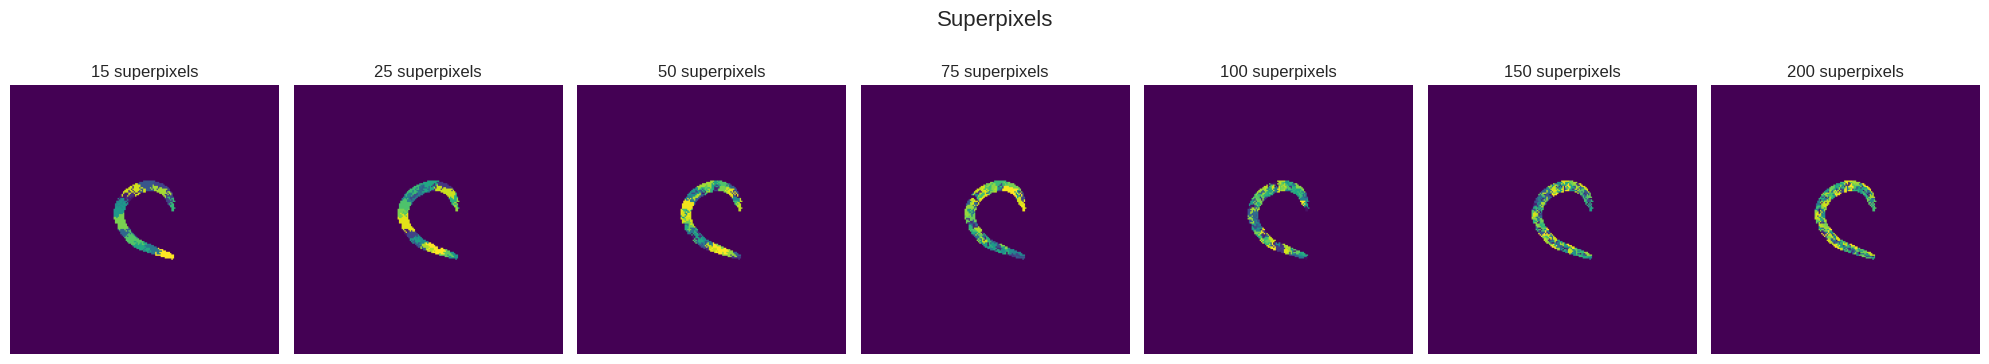

In [27]:
# Sort the superpixel values for consistent visualization order
seed = 42
ordered_superpixels = sorted(superpixels_values)
print(f"{ordered_superpixels=}")
fig, axes = plt.subplots(1, len(ordered_superpixels), figsize=(20, 4))
fig.suptitle('Superpixels', fontsize=16)

# For each superpixel value, display the first image for the selected seed
for i, superpixel in enumerate(ordered_superpixels):
    img_files = superpixel_images[f'super{superpixel}'][f'superpixels_seed{seed}']
    if img_files:
        img_path = img_files[0]
        img = plt.imread(img_path)
        axes[i].imshow(img.squeeze(), cmap='viridis')
        axes[i].set_title(f'{superpixel} superpixels')
        axes[i].axis('off')

plt.tight_layout()
plt.show()


In [28]:
# Mode of the number of features per superpixel
nfeat_mode = df_nsuper.groupby('superpixel')['nfeat'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
nfeat_mode = nfeat_mode.sort_values()
# Display the mode of number of features per superpixel as a table
display(nfeat_mode.to_frame().rename(columns={'nfeat': 'Mode of nfeat'}))


,Mode of nfeat
superpixel,
15,3630
25,6050
50,12100
75,18150
100,24200
150,36300
200,48400


In [29]:
# Perform Wilcoxon signed-rank test for all pairs of superpixel values
wilcoxon_results = pd.DataFrame(columns=['superpixel1', 'superpixel2', 'statistic', 'p_value'])

for i in range(len(ordered_superpixels)):
    for j in range(i + 1, len(ordered_superpixels)):
        sp1 = ordered_superpixels[i]
        sp2 = ordered_superpixels[j]
        
        data_sp1 = df_nsuper[df_nsuper['superpixel'] == sp1]['global_accuracy']
        data_sp2 = df_nsuper[df_nsuper['superpixel'] == sp2]['global_accuracy']
        
        # Only perform the test if sample sizes are equal and greater than 0
        if len(data_sp1) > 0 and len(data_sp2) > 0 and len(data_sp1) == len(data_sp2):
            statistic, p_value = wilcoxon(data_sp1, data_sp2)
            wilcoxon_results.loc[len(wilcoxon_results)] = {
                'superpixel1': sp1,
                'superpixel2': sp2,
                'statistic': statistic,
                'p_value': p_value
            }

print("Wilcoxon test results:")
print(wilcoxon_results)

significant = wilcoxon_results[wilcoxon_results['p_value'] < 0.05]
print("Comparisons with statistically significant difference:")
print(significant)
print(f"Total significant comparisons: {len(significant)} out of {len(wilcoxon_results)}")


Wilcoxon test results:
    superpixel1  superpixel2  statistic   p_value
0            15           25       13.5  0.167969
1            15           50        5.0  0.017578
2            15           75       20.0  0.474609
3            15          100       17.5  0.574219
4            15          150       10.0  0.080078
5            15          200        6.0  0.027344
6            25           50       12.0  0.125000
7            25           75       22.5  0.640625
8            25          100       27.0  1.000000
9            25          150       17.5  0.335938
10           25          200        5.5  0.021484
11           50           75       24.0  0.769531
12           50          100        7.0  0.148438
13           50          150       18.0  1.000000
14           50          200       15.0  0.232422
15           75          100       23.5  0.718750
16           75          150       24.0  0.750000
17           75          200       13.5  0.171875
18          100          15

In [ ]:
# Path to the experiments directory
dir_experiments = "../experiments/nsuperpixels/results"

# Dicionários separados
results_files_pred = defaultdict(dict)
superpixel_images = defaultdict(dict)

# Traverse the experiments directory
for superpixel_folder in sorted(os.listdir(dir_experiments)):
    superpixel_path = os.path.join(dir_experiments, superpixel_folder)
    if os.path.isdir(superpixel_path) and superpixel_folder.startswith("super"):
        # Armazena arquivos de resultados
        for file in sorted(os.listdir(superpixel_path)):
            if file.endswith("layer3_test1-classified-images.csv"):
                seed = int(file.split('_')[0].replace('seed', ''))
                superpixel = int(superpixel_folder.replace('super', ''))
                with open(os.path.join(superpixel_path, file), 'r') as f:
                    lines = f.readlines()
                    correct_class = []
                    predicted_class = []
                    img_name = []
                    for line in lines:
                        parts = line.strip().split(';')
                        if len(parts) >= 2:
                            img_name.append(parts[0])
                            correct_class.append(int(parts[1]))
                            predicted_class.append(int(parts[2]))
                results_files_pred[superpixel][seed] = {'img_name': img_name, 'correct': correct_class, 'predicted': predicted_class}

In [95]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# montar matriz de confusão para cada superpixel e semente
confusion_matrices = {}
for superpixel, seeds_data in results_files_pred.items():
    confusion_matrices[superpixel] = {}
    for seed, data in seeds_data.items():
        correct = np.array(data['correct'])
        # qtd de amostras por classe
        unique, counts = np.unique(correct, return_counts=True)
        class_distribution = dict(zip(unique, counts))
        # print(f"Superpixel: {superpixel}, Seed: {seed}, Class distribution: {class_distribution}")
        predicted = np.array(data['predicted'])
        # Create confusion matrix
        cm = pd.crosstab(correct, predicted, rownames=['Actual'], colnames=['Predicted'], dropna=False)
        confusion_matrices[superpixel][seed] = cm
        
# Example: Display confusion matrix for superpixel=100 and seed=42
# superpixel_to_display = 100
# seed_to_display = 42
# if superpixel_to_display in confusion_matrices and seed_to_display in confusion_matrices[superpixel_to_display]:
#     cm = confusion_matrices[superpixel_to_display][seed_to_display]
#     print(f"Confusion Matrix for Superpixel={superpixel_to_display}, Seed={seed_to_display}:\n{cm}")

evaluation_metrics = []
for superpixel, seeds_data in results_files_pred.items():
    for seed, data in seeds_data.items():
        y_true = data['correct']
        y_pred = data['predicted']
        cm = confusion_matrix(y_true, y_pred, labels=[1, 2])
        tn, fp, fn, tp = cm.ravel()
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='macro')
        recall = recall_score(y_true, y_pred, average='macro')
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = f1_score(y_true, y_pred, average='macro')
        evaluation_metrics.append({
            "superpixel": superpixel,
            "seed": seed,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "specificity": specificity
        })
        
df_metrics = pd.DataFrame(evaluation_metrics)
# media para cada superpixel
df_metrics_mean = df_metrics.groupby('superpixel').mean().reset_index()
df_metrics_mean

# mostrar codigo latex 
# df_metrics = pd.DataFrame(evaluation_metrics)
# df_metrics_mean = df_metrics.groupby('superpixel').mean().reset_index()
# df_metrics_mean
# latex_table = df_metrics_mean.to_latex(float_format="%.6f")
# print(latex_table)

,superpixel,seed,accuracy,precision,recall,f1,specificity
0,15,2970.3,0.965623,0.926382,0.917270,0.921652,0.852466
1,25,2970.3,0.967274,0.930866,0.920323,0.925203,0.857399
2,50,2970.3,0.969152,0.931555,0.928872,0.930149,0.874888
3,75,2970.3,0.967957,0.931266,0.923013,0.926866,0.862780
4,100,2970.3,0.967046,0.928288,0.922683,0.925243,0.863229
5,150,2970.3,0.969152,0.932849,0.927530,0.930037,0.871749
6,200,2970.3,0.971201,0.938045,0.931195,0.934534,0.877578


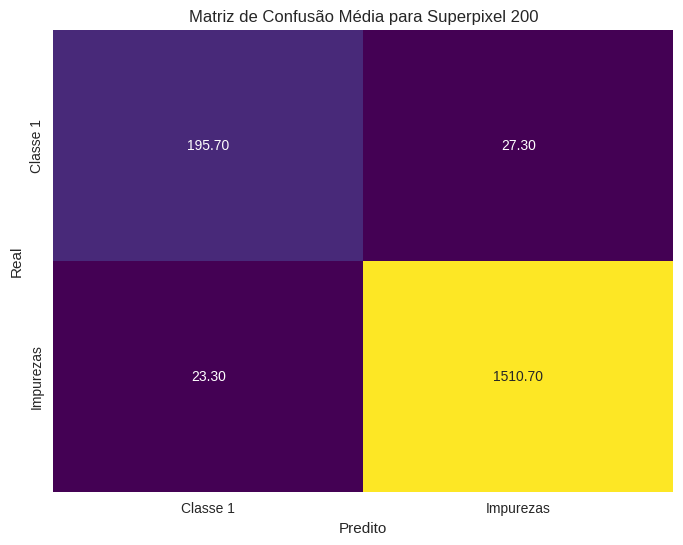

In [93]:
class_names = ['Classe 1', 'Impurezas']
superpixel_to_display = 200
if superpixel_to_display in confusion_matrices:
    cm_mean = sum(confusion_matrices[superpixel_to_display].values()) / len(confusion_matrices[superpixel_to_display])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_mean, annot=True, fmt=".2f", cmap="viridis",
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    plt.title(f"Matriz de Confusão Média para Superpixel {superpixel_to_display}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()
